In [3]:
from ultralytics import YOLO
import torch
model=YOLO(r"D:\ppt\aiml\New folder\project1\models\best.pt")
print(model.state_dict())

WARNING Ultralytics settings reset to default values. This may be due to a possible problem with your settings or a recent ultralytics package update. 
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\D.Teju\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
OrderedDict([('model.model.0.conv.weight', tensor([[[[-8.5889e-01, -1.9727e-01,  9.1846e-01],
          [-1.2129e+00, -1.8030e-01,  1.2539e+00],
          [-8.4668e-01, -3.3203e-02,  1.1592e+00]],

         [[-8.3105e-01, -2.1704e-01,  8.4131e-01],
          [-1.2178e+00, -2.2803e-01,  1.1631e+00],
          [-7.9883e-01, -5.9296e-02,  1.0391e+00]],

         [[-4.9268e-01, -1.0944e-01,  6.0205e-01],
          [-8.2617e-01, -1.2598e-01,  8.3545e-01],
          [-4.9414e-01, -7.3195e-04,  7.4658e-01]]],


        [[[-4.1406e-01, -3.9233e-01, -3.9526e-01],
       

In [4]:
!nvidia-smi


Sun Mar 22 17:57:46 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 581.04                 Driver Version: 581.04         CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3050 ...  WDDM  |   00000000:01:00.0  On |                  N/A |
| N/A   47C    P8              3W /   75W |    1025MiB /   6144MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
import torch
print(torch.cuda.is_available())

False


In [ ]:
import os
import json
import random
import torch
from torch.utils.data import Dataset
from PIL import Image
import torchvision.transforms as T
import torchvision.transforms.functional as F
import numpy as np
import cv2


def mosaic_augmentation(images, targets, input_size=(640, 640)):
    """Combine four images into one mosaic image with adjusted targets."""
    import torchvision.transforms.functional as F
    h, w = input_size
    mosaic_img = Image.new('RGB', (w * 2, h * 2))
    mosaic_targets = {'boxes': [], 'labels': []}

    # Coordinates for placement in mosaic
    placements = [(0, 0), (w, 0), (0, h), (w, h)]

    for i, img in enumerate(images):
        img = img.resize(input_size)
        mosaic_img.paste(img, placements[i])

        # Adjust boxes in targets[i] according to placement
        if targets[i]['boxes'].shape[0] > 0:
            boxes = targets[i]['boxes'].clone()
            boxes[:, [0, 2]] += placements[i][0]
            boxes[:, [1, 3]] += placements[i][1]
            mosaic_targets['boxes'].append(boxes)
            mosaic_targets['labels'].append(targets[i]['labels'])

    if mosaic_targets['boxes']:
        mosaic_targets['boxes'] = torch.cat(mosaic_targets['boxes'], dim=0)
        mosaic_targets['labels'] = torch.cat(mosaic_targets['labels'], dim=0)
    else:
        mosaic_targets['boxes'] = torch.zeros((0, 4))
        mosaic_targets['labels'] = torch.zeros((0,))

    # Resize down to input_size
    mosaic_img = mosaic_img.resize(input_size)

    # Scale boxes accordingly
    scale = 0.5  # Because mosaic is 2x2 input_size
    if mosaic_targets['boxes'].shape[0] > 0:
        mosaic_targets['boxes'] *= scale

    return mosaic_img, mosaic_targets


class DogDetectionDataset(Dataset):
    def __init__(self, root_dir, ann_file, transform=None, resize=(640, 640), augment=False, stage=1):
        self.root_dir = root_dir
        self.transform = transform
        self.resize = resize
        self.augment = augment
        self.stage = stage  # 1 for frozen layers, 2 for full fine-tuning

        with open(ann_file, 'r') as f:
            self.coco = json.load(f)

        self.images = {img['id']: img for img in self.coco['images']}
        self.annotations = {}
        for ann in self.coco['annotations']:
            self.annotations.setdefault(ann['image_id'], []).append(ann)

        self.image_ids = list(self.images.keys())

        cat_ids = sorted([cat['id'] for cat in self.coco['categories']])
        self.cat_id_map = {orig: idx for idx, orig in enumerate(cat_ids)}
        self.categories = {self.cat_id_map[cat['id']]: cat['name'] for cat in self.coco['categories']}

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        if self.stage == 2 and self.augment and random.random() < 0.5:
            # Mosaic augmentation in stage 2 with 50% chance
            indices = [idx] + random.sample(range(len(self)), 3)
            images = []
            targets = []
            for i in indices:
                img, target = self.load_image_target(i)
                images.append(img)
                targets.append(target)
            img, target = mosaic_augmentation(images, targets, self.resize)
        else:
            img, target = self.load_image_target(idx)
            if self.augment:
                img, target = self.apply_basic_augmentations(img, target)

        if self.transform:
            img = self.transform(img)

        return img, target

    def load_image_target(self, idx):
        img_id = self.image_ids[idx]
        img_info = self.images[img_id]
        img_path = os.path.join(self.root_dir, img_info['file_name'])
        image = Image.open(img_path).convert('RGB')
        orig_w, orig_h = image.size

        anns = self.annotations.get(img_id, [])
        boxes, labels = [], []

        for ann in anns:
            x, y, w, h = ann['bbox']
            boxes.append([x, y, x + w, y + h])
            labels.append(self.cat_id_map[ann['category_id']])

        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)

        if self.resize:
            new_h, new_w = self.resize
            image = F.resize(image, (new_h, new_w))
            scale_x, scale_y = new_w / orig_w, new_h / orig_h
            if boxes.shape[0] > 0:
                boxes[:, [0, 2]] *= scale_x
                boxes[:, [1, 3]] *= scale_y

        target = {
            'boxes': boxes,
            'labels': labels,
            'image_id': torch.tensor([img_id]),
            'area': (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1]) if boxes.shape[0] > 0 else torch.tensor([]),
            'iscrowd': torch.zeros((len(labels),), dtype=torch.int64)
        }

        return image, target

    def apply_basic_augmentations(self, image, target):
        boxes = target['boxes']
        new_w, new_h = self.resize
        # Horizontal flip
        if random.random() < 0.5:
            image = F.hflip(image)
            if boxes.shape[0] > 0:
                boxes[:, [0, 2]] = new_w - boxes[:, [2, 0]]
                target['boxes'] = boxes

        # Color jitter
        color_jitter = T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05)
        image = color_jitter(image)

        # Motion blur
        if random.random() < 0.3:
            img_np = np.array(image)
            ksize = random.choice([3,5,7,9])
            kernel = np.zeros((ksize, ksize))
            if random.random() < 0.5:
                kernel[int((ksize-1)/2), :] = np.ones(ksize)
            else:
                kernel[:, int((ksize-1)/2)] = np.ones(ksize)
            kernel /= ksize
            img_np = cv2.filter2D(img_np, -1, kernel)
            image = Image.fromarray(img_np)

        return image, target


In [4]:
from torch.utils.data import DataLoader

def collate_fn(batch):
    """Custom collate function to handle variable-sized targets"""
    return tuple(zip(*batch))


def create_dataloaders(base_path, batch_size=8, num_workers=0, resize=(640, 640),
                       augment=True, stage=1):
    """
    Create train, valid, and test dataloaders for Dog Detection.

    Args:
        base_path (str): base dataset directory path.
        batch_size (int): batch size.
        num_workers (int): DataLoader workers.
        resize (tuple): image resize dimensions.
        augment (bool): apply augmentations in training split.
        stage (int): 1 for frozen-layer stage (lighter augmentation),
                     2 for full fine-tuning (stronger augmentation).
    """

    transform = T.Compose([
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406],
                    std=[0.229, 0.224, 0.225])
    ])

    loaders = {}
    for split in ['train', 'valid', 'test']:
        img_dir = os.path.join(base_path, split)
        ann_file = os.path.join(base_path, split, '_annotations.coco.json')

        # Augment only for train and if augment flag is True
        do_augment = augment and split == 'train'

        dataset = DogDetectionDataset(
            root_dir=img_dir,
            ann_file=ann_file,
            transform=transform,
            resize=resize,
            augment=do_augment,
            stage=stage if split == 'train' else 1  # Use stage param only for training
        )

        shuffle = (split == 'train')
        loader = DataLoader(
            dataset,
            batch_size=batch_size,
            shuffle=shuffle,
            num_workers=num_workers,
            collate_fn=collate_fn,
            pin_memory=True
        )
        loaders[f'{split}_loader'] = loader
        print(f'{split.capitalize()} dataset: {len(dataset)} images')

    return loaders


In [5]:


# =======================
# Example usage
# =======================
base_path = r'D:\ppt\New folder\project1\dataset\DOG DETECTION.v1i.coco'

loaders = create_dataloaders(
    base_path=base_path,
    batch_size=8,
    num_workers=0,
    resize=(640, 640),
    augment=True
)

train_loader = loaders['train_loader']
val_loader = loaders['valid_loader']
test_loader = loaders['test_loader']



Train dataset: 37266 images
Valid dataset: 3609 images
Test dataset: 1866 images


In [6]:
# Test a batch
print('\nTesting train_loader:')
print(len(train_loader))
print(len(val_loader))
print(len(test_loader))



Testing train_loader:
4659
452
234


[DATA] Batch loaded in 0.509s

[INFO] Starting plot_images_targets_fast with 8 images...
[DEBUG] Resized 8 images in 0.014s
[DEBUG] make_grid done in 0.020s
[DEBUG] .cpu().numpy() on grid took 0.000s
[DEBUG] Drew all boxes in 0.008s


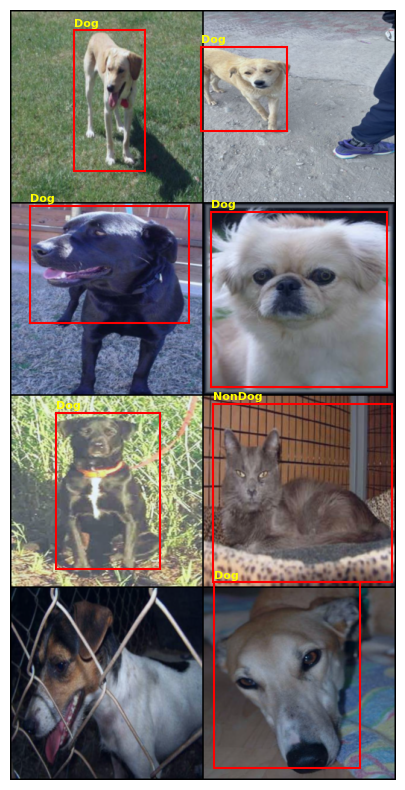

[INFO] Total time: 2.350s



In [7]:
import time
import torch
import matplotlib.pyplot as plt
import torchvision.transforms.functional as F
from torchvision.utils import make_grid

def plot_images_targets_fast(images, targets, categories, nrows=2, resize=(256, 256)):
    """
    Fast visualization using make_grid and lightweight bounding box overlay.
    Displays the grid directly instead of saving it.
    """
    print(f"\n[INFO] Starting plot_images_targets_fast with {len(images)} images...")

    t0 = time.time()

    # --- 1. Resize all images efficiently (on GPU if possible)
    t_resize = time.time()
    resized_imgs = [F.resize(img, resize) for img in images]
    print(f"[DEBUG] Resized {len(resized_imgs)} images in {time.time() - t_resize:.3f}s")

    # --- 2. Combine into a single grid
    t_grid = time.time()
    grid = make_grid(resized_imgs, nrow=nrows, normalize=True)
    print(f"[DEBUG] make_grid done in {time.time() - t_grid:.3f}s")

    # --- 3. Move grid to CPU ONCE
    t_cpu = time.time()
    grid_np = grid.permute(1, 2, 0).detach().cpu().numpy()
    print(f"[DEBUG] .cpu().numpy() on grid took {time.time() - t_cpu:.3f}s")

    # --- 4. Plot the grid
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(grid_np)
    ax.axis('off')

    # --- 5. Overlay boxes (optional)
    t_boxes = time.time()
    for i, target in enumerate(targets):
        boxes = target.get('boxes', torch.empty((0, 4))).cpu().numpy()
        labels = target.get('labels', torch.empty((0,), dtype=torch.int64)).cpu().numpy()

        if len(boxes) == 0:
            continue

        orig_h, orig_w = images[i].shape[1:]
        scale_x = resize[1] / orig_w
        scale_y = resize[0] / orig_h

        # Compute grid cell position (for offset)
        row, col = divmod(i, nrows)
        offset_x = col * resize[1]
        offset_y = row * resize[0]

        for box, label in zip(boxes, labels):
            x1, y1, x2, y2 = box
            x1, y1, x2, y2 = (
                x1 * scale_x + offset_x,
                y1 * scale_y + offset_y,
                x2 * scale_x + offset_x,
                y2 * scale_y + offset_y
            )
            width, height = x2 - x1, y2 - y1

            rect = plt.Rectangle((x1, y1), width, height,
                                 fill=False, color='red', linewidth=1.5)
            ax.add_patch(rect)
            cat_name = categories.get(int(label), str(label))
            ax.text(x1, max(0, y1 - 5), cat_name,
                    color='yellow', fontsize=8, weight='bold')

    print(f"[DEBUG] Drew all boxes in {time.time() - t_boxes:.3f}s")

    # --- 6. Display and cleanup
    plt.tight_layout()
    plt.show(block=False)  # non-blocking display
    plt.pause(2)  # keep visible for a short time if running as script
    plt.close(fig)

    print(f"[INFO] Total time: {time.time() - t0:.3f}s\n")


# Example usage
t_load = time.time()
images, targets = next(iter(test_loader))
print(f"[DATA] Batch loaded in {time.time() - t_load:.3f}s")

categories = {1: "Dog", 2: "NonDog"}
plot_images_targets_fast(images, targets, categories, nrows=2, resize=(256, 256))


In [9]:
%pip install ultralytics==8.3.0 motmetrics  ffmpeg-python   moviepy lap  

   ---------------------------------------- 0.0/881.3 kB ? eta -:--:--
   ---------------------------------------- 881.3/881.3 kB 7.8 MB/s  0:00:00
   ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
   - -------------------------------------- 0.5/15.8 MB 3.4 MB/s eta 0:00:05
   --- ------------------------------------ 1.6/15.8 MB 3.8 MB/s eta 0:00:04
   ----- ---------------------------------- 2.4/15.8 MB 3.8 MB/s eta 0:00:04
   ------- -------------------------------- 3.1/15.8 MB 3.8 MB/s eta 0:00:04
   --------- ------------------------------ 3.9/15.8 MB 3.8 MB/s eta 0:00:04
   ----------- ---------------------------- 4.7/15.8 MB 3.8 MB/s eta 0:00:03
   ------------- -------------------------- 5.5/15.8 MB 3.9 MB/s eta 0:00:03
   --------------- ------------------------ 6.3/15.8 MB 3.9 MB/s eta 0:00:03
   ----------------- ---------------------- 7.1/15.8 MB 3.9 MB/s eta 0:00:03
   ------------------- -------------------- 7.9/15.8 MB 3.8 MB/s eta 0:00:03
   ---------

In [ ]:
splits = ["train", "valid", "test"]
for split in splits:
    ann_path = rf"D:\ppt\New folder\project1\dataset\DOG DETECTION.v1i.coco\{split}\_annotations.coco.json"
    out_dir = rf"D:\ppt\New folder\project1\dataset\DOG DETECTION.v1i.coco\labels/{split}"
    os.makedirs(out_dir, exist_ok=True) #"D:\ppt\New folder\project1\dataset\DOG DETECTION.v1i.coco\train\_annotations.coco.json"

    with open(ann_path, "r") as f:
        coco = json.load(f)

    id_map = {1: 0, 2: 1}  # Dog=0, NonDog=1

    # Group annotations by image
    anns_by_img = {}
    for ann in coco["annotations"]:
        img_id = ann["image_id"]
        anns_by_img.setdefault(img_id, []).append(ann)

    for img in coco["images"]:
        file_stem = os.path.splitext(img["file_name"])[0]
        w, h = img["width"], img["height"]
        anns = anns_by_img.get(img["id"], [])

        with open(os.path.join(out_dir, f"{file_stem}.txt"), "w") as f:
            for ann in anns:
                x, y, bw, bh = ann["bbox"]
                x_c = (x + bw / 2) / w
                y_c = (y + bh / 2) / h
                bw_n = bw / w
                bh_n = bh / h
                cls = id_map[ann["category_id"]]
                f.write(f"{cls} {x_c:.6f} {y_c:.6f} {bw_n:.6f} {bh_n:.6f}\n")

print("[INFO] COCO → YOLO TXT conversion complete for all splits.")

[INFO] COCO → YOLO TXT conversion complete for all splits.


In [1]:
import os
import shutil
from tqdm import tqdm

# ------------------------------
# Paths
# ------------------------------
base_path = r"D:\ppt\New folder\project1\dataset\DOG DETECTION.v1i.coco"
image_train_dir = os.path.join(base_path, "train")
image_valid_dir = os.path.join(base_path, "valid")
label_train_dir = os.path.join(base_path, "labels", "train")
label_valid_dir = os.path.join(base_path, "labels", "valid")

# ------------------------------
# Utility Function
# ------------------------------
def move_labels(label_dir, image_dir, copy=False):
    """Move or copy label files to corresponding image directory."""
    if not os.path.exists(label_dir):
        print(f"[WARNING] Label directory not found: {label_dir}")
        return

    label_files = [f for f in os.listdir(label_dir) if f.endswith(".txt")]
    if not label_files:
        print(f"[WARNING] No label files found in {label_dir}")
        return

    action = "Copying" if copy else "Moving"
    print(f"[INFO] {action} {len(label_files)} label files from {label_dir} → {image_dir}")

    for label_file in tqdm(label_files, desc=f"{action} labels", ncols=80):
        label_path = os.path.join(label_dir, label_file)
        dest_path = os.path.join(image_dir, label_file)
        try:
            if copy:
                shutil.copy(label_path, dest_path)
            else:
                shutil.move(label_path, dest_path)
        except Exception as e:
            print(f"[ERROR] Could not move {label_file}: {e}")

    print(f"[INFO] {action} complete for {label_dir}")

# ------------------------------
# Execute
# ------------------------------
move_labels(label_train_dir, image_train_dir, copy=False)
move_labels(label_valid_dir, image_valid_dir, copy=False)

print("\n✅ All label files are now placed next to their corresponding images.")


[INFO] Moving 37266 label files from D:\ppt\New folder\project1\dataset\DOG DETECTION.v1i.coco\labels\train → D:\ppt\New folder\project1\dataset\DOG DETECTION.v1i.coco\train


Moving labels: 100%|█████████████████████| 37266/37266 [00:37<00:00, 999.45it/s]


[INFO] Moving complete for D:\ppt\New folder\project1\dataset\DOG DETECTION.v1i.coco\labels\train
[INFO] Moving 3609 label files from D:\ppt\New folder\project1\dataset\DOG DETECTION.v1i.coco\labels\valid → D:\ppt\New folder\project1\dataset\DOG DETECTION.v1i.coco\valid


Moving labels: 100%|██████████████████████| 3609/3609 [00:02<00:00, 1333.32it/s]

[INFO] Moving complete for D:\ppt\New folder\project1\dataset\DOG DETECTION.v1i.coco\labels\valid

✅ All label files are now placed next to their corresponding images.


In [1]:
import os

def clean_duplicate_labels(image_dir):
    label_files = [f for f in os.listdir(image_dir) if f.endswith(".txt")]
    print(f"[INFO] Found {len(label_files)} label files in {image_dir}")

    content_map = {}

    for label_file in label_files:
        label_path = os.path.join(image_dir, label_file)
        with open(label_path, 'r') as f:
            content = f.read()

        if label_file in content_map:
            if content_map[label_file] == content:
                print(f"[DUPLICATE] Removing exact duplicate: {label_file}")
                os.remove(label_path)
            else:
                print(f"[WARNING] {label_file} duplicate filename with different content found. Keeping latest.")
                os.remove(os.path.join(image_dir, label_file))
            content_map[label_file] = content
        else:
            content_map[label_file] = content

    print(f"[INFO] Duplicate label cleanup complete for {image_dir}")

base_path = r"D:\ppt\New folder\project1\dataset\DOG DETECTION.v1i.coco"
image_train_dir = os.path.join(base_path, "train")
image_valid_dir = os.path.join(base_path, "valid")

clean_duplicate_labels(image_train_dir)
clean_duplicate_labels(image_valid_dir)

print("\n✅ Duplicate label files have been cleaned (in-place) in both train and valid folders.")


[INFO] Found 37266 label files in D:\ppt\New folder\project1\dataset\DOG DETECTION.v1i.coco\train
[INFO] Duplicate label cleanup complete for D:\ppt\New folder\project1\dataset\DOG DETECTION.v1i.coco\train
[INFO] Found 3609 label files in D:\ppt\New folder\project1\dataset\DOG DETECTION.v1i.coco\valid
[INFO] Duplicate label cleanup complete for D:\ppt\New folder\project1\dataset\DOG DETECTION.v1i.coco\valid

✅ Duplicate label files have been cleaned (in-place) in both train and valid folders.


In [8]:
import os

base_path = r"D:\ppt\New folder\project1\dataset\DOG DETECTION.v1i.coco"
image_train_dir = os.path.join(base_path, "train")
image_valid_dir = os.path.join(base_path, "valid")

dog_class_id = "0"

def count_labels_in_dir(directory):
    dog_count = 0
    non_dog_count = 0
    files = [f for f in os.listdir(directory) if f.endswith(".txt")]
    for file in files:
        with open(os.path.join(directory, file), 'r') as f:
            for line in f:
                if line.strip():
                    class_id = line.split()[0]
                    if class_id == dog_class_id:
                        dog_count += 1
                    else:
                        non_dog_count += 1
    return dog_count, non_dog_count

train_dog, train_non_dog = count_labels_in_dir(image_train_dir)
valid_dog, valid_non_dog = count_labels_in_dir(image_valid_dir)

print(f"Train folder - Dog labels: {train_dog}, Non-dog labels: {train_non_dog}")
print(f"Valid folder - Dog labels: {valid_dog}, Non-dog labels: {valid_non_dog}")


Train folder - Dog labels: 46883, Non-dog labels: 14411
Valid folder - Dog labels: 4403, Non-dog labels: 2410


In [ ]:
# ------------------------------
# Step 2: Generate YOLO data YAML (labels next to images)
# ------------------------------
yaml_path = os.path.join(base_path, "dogdata.yaml")
yaml_content = f"""
train: {os.path.join(base_path, 'train')}
val: {os.path.join(base_path, 'valid')}

nc: 2
names: ['Dog', 'NonDog']
"""

with open(yaml_path, "w") as f:
    f.write(yaml_content.strip())

print(f"[INFO] YOLO data YAML saved to {yaml_path}")


[INFO] YOLO data YAML saved to D:\ppt\New folder\project1\dataset\DOG DETECTION.v1i.coco\dogdata.yaml


In [10]:
import os
import random
import torch
import numpy as np
from datetime import datetime
from tqdm import tqdm
from ultralytics import YOLO

# ----------------------------
# 2️⃣ Training parameters
# ----------------------------
train_yaml = r"D:\ppt\New folder\project1\dataset\DOG DETECTION.v1i.coco\dogdata.yaml"
pretrained_weights = r"D:\ppt\New folder\project1\yolo11_stanford_dog_detection_huggingface-main\best.pt"
imgsz = 640
batch_size = 8
device = 0
epochs_stage1 = 5
epochs_stage2 = 20
lr_head = 0.0001
lr_full = 0.0003
weight_decay = 0.0005
freeze_layers = [10]
augment = True
label_smoothing = 0.01

d:\miniconda3\envs\dogdeterr\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [11]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

print(f"[INFO] Torch version: {torch.__version__}")
print(f"[INFO] CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"[INFO] GPU: {torch.cuda.get_device_name(0)}")

[INFO] Torch version: 2.3.1
[INFO] CUDA available: True
[INFO] GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [12]:
import time
from tqdm import tqdm
from ultralytics import YOLO
# ----------------------------
# 3️⃣ Load pretrained model
# ----------------------------
model = YOLO(pretrained_weights)
model.model.nc = 2
model.model.names = ["not dog", "dog"]

# ----------------------------
# 4️⃣ Stage 1: Head training (freeze backbone)
# ----------------------------
for name, param in model.model.named_parameters():
    if "head" not in name:
        param.requires_grad = False
print("[INFO] Backbone frozen, only head trainable")


[INFO] Backbone frozen, only head trainable


In [ ]:
# ----------------------------
# 5️⃣ Stage 1: Head Training
# ----------------------------

for epoch in tqdm(range(epochs_stage1), desc="Stage 1 Training"):
    model.train(
        data=train_yaml,
        epochs=1,              # train one epoch at a time
        imgsz=imgsz,
        batch=batch_size,
        device=device,
        optimizer="AdamW",
        lr0=lr_head,
        weight_decay=weight_decay,
        warmup_epochs=3,
        seed=42,
        augment=augment,
        label_smoothing=label_smoothing,
        freeze=freeze_layers,
        name="dog_notdog_head_train"
    )


Stage 1 Training:   0%|          | 0/5 [00:00<?, ?it/s]

New https://pypi.org/project/ultralytics/8.3.221 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.0  Python-3.10.19 torch-2.3.1 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
engine\trainer: task=detect, mode=train, model=D:\ppt\New folder\project1\yolo11_stanford_dog_detection_huggingface-main\best.pt, data=D:\ppt\New folder\project1\dataset\DOG DETECTION.v1i.coco\dogdata.yaml, epochs=1, time=None, patience=100, batch=8, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=None, name=dog_notdog_head_train11, exist_ok=False, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=[10], multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_str

train: Scanning D:\ppt\New folder\project1\dataset\DOG DETECTION.v1i.coco\train.cache... 37266 images, 80 backgrounds, 0 corrupt: 100%|██████████| 37266/37266 [00:00<?, ?it/s]

train: WARNING  D:\ppt\New folder\project1\dataset\DOG DETECTION.v1i.coco\train\101_jpg.rf.7bb4547ef70d297d80e657c9adead1b5.jpg: 2 duplicate labels removed
train: WARNING  D:\ppt\New folder\project1\dataset\DOG DETECTION.v1i.coco\train\101_jpg.rf.9b19f4d09ee21f0d92664630a3962c7c.jpg: 2 duplicate labels removed
train: WARNING  D:\ppt\New folder\project1\dataset\DOG DETECTION.v1i.coco\train\101_jpg.rf.af2f089919d618ac4525c7a04cb78d52.jpg: 2 duplicate labels removed
train: WARNING  D:\ppt\New folder\project1\dataset\DOG DETECTION.v1i.coco\train\104_jpg.rf.6ffa440d16e023eae9de1802959a9c2c.jpg: 2 duplicate labels removed
train: WARNING  D:\ppt\New folder\project1\dataset\DOG DETECTION.v1i.coco\train\104_jpg.rf.f5512f787c280756fdd3cfb8caa9e4a1.jpg: 2 duplicate labels removed
train: WARNING  D:\ppt\New folder\project1\dataset\DOG DETECTION.v1i.coco\train\104_jpg.rf.f6993145d694ee5bdff633df59cfd1a1.jpg: 2 duplicate labels removed
train: WARNING  D:\ppt\New folder\project1\dataset\DOG DETECTION


val: Scanning D:\ppt\New folder\project1\dataset\DOG DETECTION.v1i.coco\valid.cache... 3609 images, 207 backgrounds, 0 corrupt: 100%|██████████| 3609/3609 [00:00<?, ?it/s]

...

        1/1      1.55G      1.246      1.536      1.504          7        640: 100%|██████████| 4659/4659 [16:30<00:00,  4.70it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 226/226 [00:43<00:00,  5.18it/s]


                   all       3609       6811      0.236      0.298      0.243      0.126

1 epochs completed in 0.290 hours.
Optimizer stripped from runs\detect\dog_notdog_head_train15\weights\last.pt, 5.5MB
Optimizer stripped from runs\detect\dog_notdog_head_train15\weights\best.pt, 5.5MB

Validating runs\detect\dog_notdog_head_train15\weights\best.pt...
Ultralytics 8.3.0  Python-3.10.19 torch-2.3.1 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
YOLO11n summary (fused): 238 layers, 2,582,542 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 226/226 [01:01<00:00,  3.70it/s]


                   all       3609       6811      0.267        0.3      0.254      0.134
                   Dog       2262       4401      0.413      0.591      0.395      0.205
                NonDog       1140       2410      0.121     0.0083      0.112     0.0628
Speed: 0.3ms preprocess, 10.1ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to runs\detect\dog_notdog_head_train15


Stage 1 Training: 100%|██████████| 5/5 [1:48:22<00:00, 1300.59s/it]


In [ ]:
# ----------------------------
# 6️⃣ Stage 2: full fine-tuning (unfreeze backbone)
# ----------------------------
for param in model.model.parameters():
    param.requires_grad = True
print(f"[INFO] Stage 2: Full fine-tuning, backbone unfrozen")

for epoch in tqdm(range(epochs_stage2), desc="Stage 2 Training"):
    model.train(
        data=train_yaml,
        epochs=1,
        imgsz=imgsz,
        batch=batch_size,
        device=device,
        optimizer="AdamW",
        lr0=lr_full,
        weight_decay=weight_decay,
        warmup_epochs=3,
        augment=augment,
        label_smoothing=label_smoothing,
        name="dog_notdog_full_finetune"
    )


[INFO] Stage 2: Full fine-tuning, backbone unfrozen


Stage 2 Training:   0%|          | 0/20 [00:00<?, ?it/s]

New https://pypi.org/project/ultralytics/8.3.221 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.0  Python-3.10.19 torch-2.3.1 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
engine\trainer: task=detect, mode=train, model=D:\ppt\New folder\project1\yolo11_stanford_dog_detection_huggingface-main\best.pt, data=D:\ppt\New folder\project1\dataset\DOG DETECTION.v1i.coco\dogdata.yaml, epochs=1, time=None, patience=100, batch=8, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=None, name=dog_notdog_full_finetune, exist_ok=False, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=[10], multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_st

train: Scanning D:\ppt\New folder\project1\dataset\DOG DETECTION.v1i.coco\train.cache... 37266 images, 80 backgrounds, 0 corrupt: 100%|██████████| 37266/37266 [00:00<?, ?it/s]

train: WARNING  D:\ppt\New folder\project1\dataset\DOG DETECTION.v1i.coco\train\101_jpg.rf.7bb4547ef70d297d80e657c9adead1b5.jpg: 2 duplicate labels removed
train: WARNING  D:\ppt\New folder\project1\dataset\DOG DETECTION.v1i.coco\train\101_jpg.rf.9b19f4d09ee21f0d92664630a3962c7c.jpg: 2 duplicate labels removed
train: WARNING  D:\ppt\New folder\project1\dataset\DOG DETECTION.v1i.coco\train\101_jpg.rf.af2f089919d618ac4525c7a04cb78d52.jpg: 2 duplicate labels removed
train: WARNING  D:\ppt\New folder\project1\dataset\DOG DETECTION.v1i.coco\train\104_jpg.rf.6ffa440d16e023eae9de1802959a9c2c.jpg: 2 duplicate labels removed
train: WARNING  D:\ppt\New folder\project1\dataset\DOG DETECTION.v1i.coco\train\104_jpg.rf.f5512f787c280756fdd3cfb8caa9e4a1.jpg: 2 duplicate labels removed
train: WARNING  D:\ppt\New folder\project1\dataset\DOG DETECTION.v1i.coco\train\104_jpg.rf.f6993145d694ee5bdff633df59cfd1a1.jpg: 2 duplicate labels removed
train: WARNING  D:\ppt\New folder\project1\dataset\DOG DETECTION

In [5]:
import torch
from ultralytics import YOLO

class ExportModel(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        outputs = self.model(x)
        # outputs is a tuple → take ONLY the main prediction
        return outputs[0]


In [6]:
from ultralytics import YOLO
import torch
model = YOLO(
    r"D:\ppt\aiml\New folder\project1\runs\detect\dog_detector_one_stage2\weights\best.pt"
).model

model.eval()

export_model = ExportModel(model).eval()

dummy = torch.randn(1, 3, 320, 320)

torch.onnx.export(
    export_model,
    dummy,
    "model.onnx",
    opset_version=12,
    input_names=["images"],
    output_names=["preds"],
    dynamic_axes=None
)

print("ONNX export done")  

ONNX export done


In [8]:
import onnxruntime as ort

sess = ort.InferenceSession("model.onnx")
print(sess.get_inputs())
print(sess.get_outputs())
print([i.name for i in sess.get_inputs()])
print([o.name for o in sess.get_outputs()])



['images']
['preds']


In [9]:
!onnxsim model.onnx model_simplified.onnx


Your model contains "Tile" ops or/and "ConstantOfShape" ops. Folding these ops 
can make the simplified model much larger. If it is not expected, please 
specify "--no-large-tensor" (which will lose some optimization chances)
Simplifying...
Finish! Here is the difference:
┌─────────────────┬────────────────┬──────────────────┐
│                 │ Original Model │ Simplified Model │
├─────────────────┼────────────────┼──────────────────┤
│ Add             │ 28             │ 16               │
│ Concat          │ 28             │ 23               │
│ Constant        │ 259            │ 195              │
│ ConstantOfShape │ 3              │ 0                │
│ Conv            │ 88             │ 88               │
│ Div             │ 10             │ 1                │
│ Expand          │ 6              │ 0                │
│ Gather          │ 9              │ 0                │
│ MatMul          │ 2              │ 2                │
│ MaxPool         │ 3              │ 3                │

In [10]:
import onnxruntime as ort

sess = ort.InferenceSession("model_simplified.onnx")
print([i.name for i in sess.get_inputs()])
print([o.name for o in sess.get_outputs()])


['images']
['preds']


In [4]:
!pip install tensorflow-probability==0.19.0


   ---------------------------------------- 0.0/6.7 MB ? eta -:--:--
   ------ --------------------------------- 1.0/6.7 MB 7.1 MB/s eta 0:00:01
   --------- ------------------------------ 1.6/6.7 MB 4.2 MB/s eta 0:00:02
   ------------ --------------------------- 2.1/6.7 MB 3.7 MB/s eta 0:00:02
   ----------------- ---------------------- 2.9/6.7 MB 3.7 MB/s eta 0:00:02
   ----------------------- ---------------- 3.9/6.7 MB 3.8 MB/s eta 0:00:01
   -------------------------- ------------- 4.5/6.7 MB 3.6 MB/s eta 0:00:01
   -------------------------------- ------- 5.5/6.7 MB 3.8 MB/s eta 0:00:01
   ------------------------------------- -- 6.3/6.7 MB 3.8 MB/s eta 0:00:01
   ---------------------------------------- 6.7/6.7 MB 3.8 MB/s  0:00:01


In [5]:
!pip install onnx-tf==1.10.0



   ---------------------------------------- 0.0/719.8 kB ? eta -:--:--
   ---------------------------------------- 719.8/719.8 kB 5.8 MB/s  0:00:00

   ---------------------------------------- 0/2 [tensorflow-addons]
   ---------------------------------------- 0/2 [tensorflow-addons]
   ---------------------------------------- 0/2 [tensorflow-addons]
   ---------------------------------------- 0/2 [tensorflow-addons]
   ---------------------------------------- 0/2 [tensorflow-addons]
   ---------------------------------------- 0/2 [tensorflow-addons]
   ---------------------------------------- 0/2 [tensorflow-addons]
   ---------------------------------------- 0/2 [tensorflow-addons]
   -------------------- ------------------- 1/2 [onnx-tf]
   -------------------- ------------------- 1/2 [onnx-tf]
   -------------------- ------------------- 1/2 [onnx-tf]
   -------------------- ------------------- 1/2 [onnx-tf]
   -------------------- ------------------- 1/2 [onnx-tf]
   --------------

In [3]:
!pip install onnx==1.13.1


   ---------------------------------------- 0.0/12.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.2 MB ? eta -:--:--
    --------------------------------------- 0.3/12.2 MB ? eta -:--:--
    --------------------------------------- 0.3/12.2 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.2 MB 670.4 kB/s eta 0:00:18
   -- ------------------------------------- 0.8/12.2 MB 684.4 kB/s eta 0:00:17
   -- ------------------------------------- 0.8/12.2 MB 684.4 kB/s eta 0:00:17
   --- ------------------------------------ 1.0/12.2 MB 699.0 kB/s eta 0:00:16
   --- ------------------------------------ 1.0/12.2 MB 699.0 kB/s eta 0:00:16
   --- ------------------------------------ 1.0/12.2 MB 699.0 kB/s eta 0:00:16
   --- ------------------------------------ 1.0/12.2 MB 699.0 kB/s eta 0:00:16
   --- ------------------------------------ 1.0/12.2 MB 699.0 kB/s eta 0:00:16
   --- -----------

  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-intel 2.12.0 requires keras<2.13,>=2.12.0, which is not installed.


In [19]:
import onnxruntime as ort
import numpy as np

sess = ort.InferenceSession("model_simplified.onnx")

input_name = sess.get_inputs()[0].name
output_name = sess.get_outputs()[0].name

dummy = np.random.rand(1, 3, 320, 320).astype(np.float32)

out = sess.run([output_name], {input_name: dummy})
print(out[0].shape)


(1, 5, 2100)


In [13]:
!pip install onnxruntime onnxruntime-tools numpy opencv-python



   -------------------- ------------------- 1/2 [onnxruntime-tools]
   -------------------- ------------------- 1/2 [onnxruntime-tools]
   -------------------- ------------------- 1/2 [onnxruntime-tools]
   -------------------- ------------------- 1/2 [onnxruntime-tools]
   -------------------- ------------------- 1/2 [onnxruntime-tools]
   -------------------- ------------------- 1/2 [onnxruntime-tools]
   -------------------- ------------------- 1/2 [onnxruntime-tools]
   ---------------------------------------- 2/2 [onnxruntime-tools]



In [14]:
import onnx
import onnxruntime as ort

print("onnx:", onnx.__version__)
print("onnxruntime:", ort.__version__)


onnx: 1.13.1
onnxruntime: 1.16.3


In [16]:
import onnxruntime as ort
import numpy as np

sess = ort.InferenceSession(
    "model_int8.onnx",
    providers=["CPUExecutionProvider"]
)

input_name = sess.get_inputs()[0].name
output_name = sess.get_outputs()[0].name

dummy = np.random.rand(1, 3, 320, 320).astype(np.float32)
out = sess.run([output_name], {input_name: dummy})

print("Output shape:", out[0].shape)


Output shape: (1, 5, 2100)


In [1]:
import cv2
import numpy as np
import onnxruntime as ort
import time

# ================= CONFIG =================
MODEL_PATH = "model_int8.onnx"
VIDEO_PATH = r"C:\Users\D.Teju\Downloads\stock-footage-cute-senior-dog-walking-on-field-front-view-of-old-labrador-retriever-on-sunny-day-real-time-in.webm"

IMG_SIZE = 320

CONF_THRESH = 0.12      # ← critical for INT8
NMS_THRESH  = 0.5
# =========================================


# ---------- Load ONNX Runtime ----------
sess = ort.InferenceSession(
    MODEL_PATH,
    providers=["CPUExecutionProvider"]
)

input_name  = sess.get_inputs()[0].name
output_name = sess.get_outputs()[0].name

print("ONNX model loaded")
print("Input :", input_name)
print("Output:", output_name)

NoSuchFile: [ONNXRuntimeError] : 3 : NO_SUCHFILE : Load model from model_int8.onnx failed:Load model model_int8.onnx failed. File doesn't exist

In [3]:
cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise RuntimeError("Video not accessible")


# ---------- Main Loop ----------
while True:
    ret, frame = cap.read()
    if not ret:
        break

    h0, w0 = frame.shape[:2]

    # -------- Preprocess --------
    img = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
    img = img[:, :, ::-1]                 # BGR → RGB
    img = img.astype(np.float32) / 255.0
    img = np.transpose(img, (2, 0, 1))    # CHW
    img = np.expand_dims(img, axis=0)

    # -------- Inference --------
    t0 = time.time()
    preds = sess.run([output_name], {input_name: img})[0]
    t1 = time.time()

    fps = 1.0 / (t1 - t0)

    # preds shape: (1, 5, 2100)
    pred = preds[0].T   # (2100, 5)

    # -------- PRINT RANGES (ONCE PER FRAME) --------
    print("=" * 40)
    print("CONF RANGE :", pred[:,4].min(), pred[:,4].max())
    print("CX RANGE   :", pred[:,0].min(), pred[:,0].max())
    print("W RANGE    :", pred[:,2].min(), pred[:,2].max())
    print("SAMPLE ROW :", pred[0])

    # -------- TAKE TOP 20 BY COLUMN 4 --------
    topk = pred[pred[:,4].argsort()[::-1]][:20]

    # -------- FORCE DRAW (NO FILTERS) --------
    for row in topk:
        a, b, c, d, e = row

        # ---- Interpretation A: [cx, cy, w, h, conf] ----
        cx, cy, w, h, conf = a, b, c, d, e

        x1 = cx - w / 2
        y1 = cy - h / 2

        sx = int(x1 * w0 / IMG_SIZE)
        sy = int(y1 * h0 / IMG_SIZE)
        sw = int(w * w0 / IMG_SIZE)
        sh = int(h * h0 / IMG_SIZE)

        if sw > 5 and sh > 5:
            cv2.rectangle(
                frame,
                (sx, sy),
                (sx + sw, sy + sh),
                (0, 0, 255),   # RED
                2
            )

        # ---- Interpretation B: [conf, cx, cy, w, h] ----
        conf2, cx2, cy2, w2, h2 = a, b, c, d, e

        x1b = cx2 - w2 / 2
        y1b = cy2 - h2 / 2

        sxb = int(x1b * w0 / IMG_SIZE)
        syb = int(y1b * h0 / IMG_SIZE)
        swb = int(w2 * w0 / IMG_SIZE)
        shb = int(h2 * h0 / IMG_SIZE)

        if swb > 5 and shb > 5:
            cv2.rectangle(
                frame,
                (sxb, syb),
                (sxb + swb, syb + shb),
                (255, 0, 0),   # BLUE
                2
            )

    cv2.putText(
        frame,
        f"FPS: {fps:.1f}",
        (10, 30),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 0, 255),
        2
    )

    cv2.imshow("DEBUG INT8 ONNX OUTPUT", frame)

    if cv2.waitKey(1) & 0xFF == 27:  # ESC
        break


# ---------- Cleanup ----------
cap.release()
cv2.destroyAllWindows()

CONF RANGE : 0.0 0.0
CX RANGE   : 3.9973207 317.787
W RANGE    : 3.9973207 293.80307
SAMPLE ROW : [ 5.995981  11.991962   7.9946413 23.983925   0.       ]
CONF RANGE : 0.0 0.0
CX RANGE   : 3.9973207 319.78564
W RANGE    : 3.9973207 277.81378
SAMPLE ROW : [ 5.995981  11.991962   7.9946413 23.983925   0.       ]
CONF RANGE : 0.0 0.0
CX RANGE   : 5.995981 317.787
W RANGE    : 5.995981 313.78967
SAMPLE ROW : [ 5.995981  11.991962   7.9946413 19.986603   0.       ]
CONF RANGE : 0.0 0.0
CX RANGE   : 5.995981 319.78564
W RANGE    : 3.9973207 303.79636
SAMPLE ROW : [ 5.995981  15.989283   7.9946413 27.981245   0.       ]
CONF RANGE : 0.0 0.0
CX RANGE   : 3.9973207 317.787
W RANGE    : 5.995981 317.787
SAMPLE ROW : [ 5.995981  15.989283   7.9946413 25.982584   0.       ]
CONF RANGE : 0.0 0.0
CX RANGE   : 3.9973207 317.787
W RANGE    : 5.995981 303.79636
SAMPLE ROW : [ 5.995981  15.989283   7.9946413 27.981245   0.       ]
CONF RANGE : 0.0 0.0
CX RANGE   : 3.9973207 319.78564
W RANGE    : 5.9959

In [ ]:
import cv2
import numpy as np
import onnxruntime as ort
import time

# ================= CONFIG =================
MODEL_PATH = "model_int8.onnx"
VIDEO_PATH = r"C:\Users\D.Teju\Downloads\stock-footage-cute-senior-dog-walking-on-field-front-view-of-old-labrador-retriever-on-sunny-day-real-time-in.webm"

IMG_SIZE = 320

CONF_THRESH = 0.25      # applied AFTER sigmoid
NMS_THRESH  = 0.45
# =========================================


# ---------- Utility ----------
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


# ---------- Load ONNX ----------
sess = ort.InferenceSession(
    MODEL_PATH,
    providers=["CPUExecutionProvider"]
)

input_name  = sess.get_inputs()[0].name
output_name = sess.get_outputs()[0].name

print("ONNX model loaded")
print("Input :", input_name)
print("Output:", output_name)



OUTPUT_PATH = r"D:\ppt\aiml\New folder\project1\outputs\dog_detection_out.mp4"
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
fps_out = cap.get(cv2.CAP_PROP_FPS)
if fps_out == 0 or np.isnan(fps_out):
    fps_out = 25  # safe fallback

writer = cv2.VideoWriter(
    OUTPUT_PATH,
    fourcc,
    fps_out,
    (int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)),
     int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)))
)


# ---------- Open Video ----------
cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise RuntimeError("Video not accessible")


# ---------- Main Loop ----------
while True:
    ret, frame = cap.read()
    if not ret:
        break

    h0, w0 = frame.shape[:2]

    # -------- Preprocess --------
    img = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
    img = img[:, :, ::-1]                 # BGR → RGB
    img = img.astype(np.float32) / 255.0
    img = np.transpose(img, (2, 0, 1))    # CHW
    img = np.expand_dims(img, axis=0)

    # -------- Inference --------
    t0 = time.time()
    preds = sess.run([output_name], {input_name: img})[0]
    t1 = time.time()

    fps = 1.0 / (t1 - t0)

    # preds: (1, 5, 2100) → (2100, 5)
    pred = preds[0].T

    boxes  = []
    scores = []

    # -------- Decode (SIGMOID + PIXEL SPACE) --------
    for cx, cy, w, h, conf_logit in pred:
        conf = sigmoid(conf_logit)

        if conf < CONF_THRESH:
            continue

        # coordinates already in pixel space (0–320)
        x1 = cx - w / 2
        y1 = cy - h / 2
        bw = w
        bh = h

        boxes.append([x1, y1, bw, bh])
        scores.append(float(conf))

    # -------- NMS (NO double thresholding) --------
    final_boxes  = []
    final_scores = []

    if boxes:
        idxs = cv2.dnn.NMSBoxes(
            boxes,
            scores,
            score_threshold=0.0,   # IMPORTANT
            nms_threshold=NMS_THRESH
        )

        if len(idxs) > 0:
            for i in idxs.flatten():
                final_boxes.append(boxes[i])
                final_scores.append(scores[i])

    # -------- Draw --------
    for (x, y, w, h), conf in zip(final_boxes, final_scores):
        # scale from model space → original frame
        sx = int(x * w0 / IMG_SIZE)
        sy = int(y * h0 / IMG_SIZE)
        sw = int(w * w0 / IMG_SIZE)
        sh = int(h * h0 / IMG_SIZE)

        cv2.rectangle(
            frame,
            (sx, sy),
            (sx + sw, sy + sh),
            (0, 255, 0),
            2
        )

        cv2.putText(
            frame,
            f"DOG {conf:.2f}",
            (sx, max(0, sy - 5)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 0),
            2
        )

    cv2.putText(
        frame,
        f"FPS: {fps:.1f}",
        (10, 30),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 0, 255),
        2
    )
    writer.write(frame)
    cv2.imshow("INT8 ONNX Dog Detection", frame)

    if cv2.waitKey(1) & 0xFF == 27:   # ESC
        break


# ---------- Cleanup ----------
cap.release()
cv2.destroyAllWindows()


NoSuchFile: [ONNXRuntimeError] : 3 : NO_SUCHFILE : Load model from model_int8.onnx failed:Load model model_int8.onnx failed. File doesn't exist

In [6]:
import onnx
from onnxconverter_common import float16

model_fp32 = onnx.load("model_simplified.onnx")  # your pre-INT8 ONNX
model_fp16 = float16.convert_float_to_float16(model_fp32)

onnx.save(model_fp16, "model_fp16.onnx")
print("FP16 ONNX saved as model_fp16.onnx")


FP16 ONNX saved as model_fp16.onnx


d:\miniconda3\envs\dogdet\lib\site-packages\onnxconverter_common\float16.py:52: UserWarning: the float32 number 4.46513261920245e-08 will be truncated to 1e-07
  warnings.warn(
d:\miniconda3\envs\dogdet\lib\site-packages\onnxconverter_common\float16.py:70: UserWarning: the float32 number -5.275950343275326e-08 will be truncated to -1e-07
  warnings.warn(
d:\miniconda3\envs\dogdet\lib\site-packages\onnxconverter_common\float16.py:70: UserWarning: the float32 number -8.461507405854718e-08 will be truncated to -1e-07
  warnings.warn(
d:\miniconda3\envs\dogdet\lib\site-packages\onnxconverter_common\float16.py:52: UserWarning: the float32 number 4.7072280295878954e-08 will be truncated to 1e-07
  warnings.warn(
d:\miniconda3\envs\dogdet\lib\site-packages\onnxconverter_common\float16.py:52: UserWarning: the float32 number 2.603831372738341e-09 will be truncated to 1e-07
  warnings.warn(
d:\miniconda3\envs\dogdet\lib\site-packages\onnxconverter_common\float16.py:70: UserWarning: the float32 n

In [ ]:
import cv2
import numpy as np
import onnxruntime as ort
import time

# ================= CONFIG =================
MODEL_PATH = r"D:\ppt\aiml\New folder\project1\models\model_fp16.onnx"
VIDEO_PATH = r"C:\Users\D.Teju\Downloads\WhatsApp Video 2026-01-15 at 12.53.57.mp4"
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
IMG_SIZE = 320
CONF_THRESH = 0.4
NMS_THRESH  = 0.5
# =========================================


# ---------- Load FP16 ONNX ----------
sess = ort.InferenceSession(
    MODEL_PATH,
    providers=["CPUExecutionProvider"]
)
input_name  = sess.get_inputs()[0].name
output_name = sess.get_outputs()[0].name
OUTPUT_PATH=r"D:\ppt\aiml\New folder\project1\results"
print("FP16 ONNX loaded")
print("Input :", input_name)
print("Output:", output_name)

# ---------- Open Video FIRST ----------
cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise RuntimeError("Video not accessible")

# ---------- Get video properties ----------
video_fps = cap.get(cv2.CAP_PROP_FPS)
if video_fps <= 1:
    video_fps = 25

width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# ---------- Create VideoWriter ----------
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(
    OUTPUT_PATH,
    fourcc,
    video_fps,
    (width, height)
)



# ---------- Main Loop ----------
while True:
    ret, frame = cap.read()
    if not ret:
        break

    h0, w0 = frame.shape[:2]

    # -------- Preprocess (FP16) --------
    img = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
    img = img[:, :, ::-1]                 # BGR → RGB
    img = (img.astype(np.float32) / 255.0).astype(np.float16)
    img = np.transpose(img, (2, 0, 1))    # CHW
    img = np.expand_dims(img, axis=0)

    # -------- Inference --------
    t0 = time.time()
    preds = sess.run([output_name], {input_name: img})[0]
    t1 = time.time()
    fps = 1.0 / (t1 - t0)

    # preds: (1, 5, N) → (N, 5)
    pred = preds[0].T

    boxes  = []
    scores = []

    # -------- Decode (PIXEL SPACE, NO SIGMOID) --------
    for cx, cy, w, h, conf in pred:
        if conf < CONF_THRESH:
            continue

        # Outputs are already in pixel space
        x1 = cx - w / 2
        y1 = cy - h / 2
        bw = w
        bh = h

        boxes.append([x1, y1, bw, bh])
        scores.append(float(conf))

    # -------- NMS (single filtering) --------
    final_boxes  = []
    final_scores = []

    if boxes:
        idxs = cv2.dnn.NMSBoxes(
            boxes,
            scores,
            score_threshold=0.0,
            nms_threshold=NMS_THRESH
        )

        if len(idxs) > 0:
            for i in idxs.flatten():
                final_boxes.append(boxes[i])
                final_scores.append(scores[i])

    # -------- Draw --------
    for (x, y, w, h), conf in zip(final_boxes, final_scores):
        # Scale from model input → original frame
        sx = int(x * w0 / IMG_SIZE)
        sy = int(y * h0 / IMG_SIZE)
        sw = int(w * w0 / IMG_SIZE)
        sh = int(h * h0 / IMG_SIZE)

        cv2.rectangle(frame, (sx, sy), (sx + sw, sy + sh), (0, 255, 0), 2)
        cv2.putText(
            frame,
            f"DOG {conf:.2f}",
            (sx, max(0, sy - 5)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 0),
            2
        )

    cv2.putText(
        frame,
        f"FPS: {fps:.1f}",
        (10, 30),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 0, 255),
        2
    )
    writer.release()

    cv2.imshow("FP16 ONNX Dog Detection", frame)
    if cv2.waitKey(1) & 0xFF == 27:
        break


cap.release()
cv2.destroyAllWindows()


FP16 ONNX loaded
Input : images
Output: preds


In [1]:
!pip install pyserial

In [ ]:
import cv2
import numpy as np
import onnxruntime as ort
import time
import serial

# ================= CONFIG =================
MODEL_PATH  = r"D:\ppt\aiml\New folder\project1\models\model_fp16.onnx"
VIDEO_PATH  = r"C:\Users\D.Teju\Downloads\WhatsApp Video 2026-01-15 at 12.53.57.mp4"
IMG_SIZE    = 320
CONF_THRESH = 0.4
NMS_THRESH  = 0.5
COM_PORT    = "COM3"   # ← change to your port
# ==========================================

# ---------- UART ----------
ser = serial.Serial(COM_PORT, 9600, timeout=1)
time.sleep(2)  # wait for STM32 to boot
print(f"UART connected on {COM_PORT}")

# ---------- Load ONNX ----------
sess = ort.InferenceSession(MODEL_PATH, providers=["CPUExecutionProvider"])
input_name  = sess.get_inputs()[0].name
output_name = sess.get_outputs()[0].name
print("Model loaded")

# ---------- Open Video ----------
cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise RuntimeError("Video not accessible")

# ---------- Main Loop ----------
while True:
    ret, frame = cap.read()
    if not ret:
        break

    h0, w0 = frame.shape[:2]

    # -------- Preprocess --------
    img = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
    img = img[:, :, ::-1]
    img = (img.astype(np.float32) / 255.0).astype(np.float16)
    img = np.transpose(img, (2, 0, 1))
    img = np.expand_dims(img, axis=0)

    # -------- Inference --------
    t0   = time.time()
    preds = sess.run([output_name], {input_name: img})[0]
    t1   = time.time()
    fps  = 1.0 / (t1 - t0)

    pred = preds[0].T

    boxes  = []
    scores = []

    for cx, cy, w, h, conf in pred:
        if conf < CONF_THRESH:
            continue
        x1 = cx - w / 2
        y1 = cy - h / 2
        boxes.append([x1, y1, w, h])
        scores.append(float(conf))

    final_boxes  = []
    final_scores = []

    if boxes:
        idxs = cv2.dnn.NMSBoxes(
            boxes, scores,
            score_threshold=0.0,
            nms_threshold=NMS_THRESH
        )
        if len(idxs) > 0:
            for i in idxs.flatten():
                final_boxes.append(boxes[i])
                final_scores.append(scores[i])

    # -------- UART → STM32 --------
    if len(final_boxes) > 0:
        ser.write(b'1')   # dog detected
        print(f"DOG DETECTED ({len(final_boxes)}) → sent 1 to STM32")
    else:
        ser.write(b'0')   # no dog
        print("No dog → sent 0 to STM32")

    # -------- Draw --------
    for (x, y, w, h), conf in zip(final_boxes, final_scores):
        sx = int(x * w0 / IMG_SIZE)
        sy = int(y * h0 / IMG_SIZE)
        sw = int(w * w0 / IMG_SIZE)
        sh = int(h * h0 / IMG_SIZE)
        cv2.rectangle(frame, (sx, sy), (sx + sw, sy + sh), (0, 255, 0), 2)
        cv2.putText(frame, f"DOG {conf:.2f}", (sx, max(0, sy - 5)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    # STM32 status on frame
    status = "DOG DETECTED" if final_boxes else "No Dog"
    color  = (0, 0, 255) if final_boxes else (0, 255, 0)
    cv2.putText(frame, f"STM32: {status}", (10, 60),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)
    cv2.putText(frame, f"FPS: {fps:.1f}", (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)

    cv2.imshow("Dog Detection → STM32", frame)
    if cv2.waitKey(1) & 0xFF == 27:
        break


# ---------- Cleanup ----------
ser.write(b'0')   # turn off STM32 on exit
ser.close()
cap.release()
cv2.destroyAllWindows()


SerialException: could not open port 'COM5': FileNotFoundError(2, 'The system cannot find the file specified.', None, 2)

In [7]:
import cv2
import numpy as np
import onnxruntime as ort
import time
import serial

# ================= CONFIG =================
MODEL_PATH  = r"D:\ppt\aiml\New folder\project1\models\model_fp16.onnx"
VIDEO_PATH  = r"C:\Users\D.Teju\Downloads\WhatsApp Video 2026-01-15 at 12.53.57.mp4"
IMG_SIZE    = 320
CONF_THRESH = 0.4
NMS_THRESH  = 0.5
COM_PORT    = "COM3"
BAUD_RATE   = 9600
# ==========================================

# ---------- Connect UART ----------
ser = serial.Serial(COM_PORT, BAUD_RATE, timeout=1)
time.sleep(2)
print(f"STM32 connected on {COM_PORT}")

# ---------- Load Model ----------
sess = ort.InferenceSession(
    MODEL_PATH,
    providers=["CPUExecutionProvider"]
)
input_name  = sess.get_inputs()[0].name
output_name = sess.get_outputs()[0].name
print("Model loaded")

# ---------- Open Video ----------
cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise RuntimeError("Video not accessible")

last_sent = None

# ---------- Main Loop ----------
while True:
    ret, frame = cap.read()
    if not ret:
        break

    h0, w0 = frame.shape[:2]

    # -------- Preprocess --------
    img = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
    img = img[:, :, ::-1]
    img = (img.astype(np.float32) / 255.0).astype(np.float16)
    img = np.transpose(img, (2, 0, 1))
    img = np.expand_dims(img, axis=0)

    # -------- Inference --------
    t0    = time.time()
    preds = sess.run([output_name], {input_name: img})[0]
    t1    = time.time()
    fps   = 1.0 / (t1 - t0)

    pred = preds[0].T

    boxes  = []
    scores = []

    for cx, cy, w, h, conf in pred:
        if conf < CONF_THRESH:
            continue
        x1 = cx - w / 2
        y1 = cy - h / 2
        boxes.append([x1, y1, w, h])
        scores.append(float(conf))

    final_boxes  = []
    final_scores = []

    if boxes:
        idxs = cv2.dnn.NMSBoxes(
            boxes, scores,
            score_threshold=0.0,
            nms_threshold=NMS_THRESH
        )
        if len(idxs) > 0:
            for i in idxs.flatten():
                final_boxes.append(boxes[i])
                final_scores.append(scores[i])

    # -------- Send to STM32 --------
    if len(final_boxes) > 0:
        if last_sent != '1':
            ser.write(b'1')
            last_sent = '1'
            print(f"DOG DETECTED ({len(final_boxes)}) → STM32 LED ON + PWM ON")
    else:
        if last_sent != '0':
            ser.write(b'0')
            last_sent = '0'
            print("No dog → STM32 LED OFF + PWM OFF")

    # -------- Draw --------
    for (x, y, w, h), conf in zip(final_boxes, final_scores):
        sx = int(x * w0 / IMG_SIZE)
        sy = int(y * h0 / IMG_SIZE)
        sw = int(w * w0 / IMG_SIZE)
        sh = int(h * h0 / IMG_SIZE)
        cv2.rectangle(frame, (sx, sy), (sx+sw, sy+sh), (0, 255, 0), 2)
        cv2.putText(frame, f"DOG {conf:.2f}",
                    (sx, max(0, sy-5)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    status = "DOG DETECTED" if final_boxes else "No Dog"
    color  = (0, 0, 255) if final_boxes else (0, 255, 0)
    cv2.putText(frame, f"STM32: {status}",
                (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)
    cv2.putText(frame, f"FPS: {fps:.1f}",
                (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)

    cv2.imshow("Dog Detection → STM32", frame)
    if cv2.waitKey(1) & 0xFF == 27:
        break

# ---------- Cleanup ----------
ser.write(b'0')
ser.close()
cap.release()
cv2.destroyAllWindows()
print("Done")

STM32 connected on COM3
Model loaded
DOG DETECTED (1) → STM32 LED ON + PWM ON
No dog → STM32 LED OFF + PWM OFF
DOG DETECTED (1) → STM32 LED ON + PWM ON
Done


In [6]:
import serial.tools.list_ports
for p in serial.tools.list_ports.comports():
    print(p.device, p.description)

COM11 Standard Serial over Bluetooth link (COM11)
COM10 Standard Serial over Bluetooth link (COM10)
COM3 USB-Enhanced-SERIAL CH9102 (COM3)


In [9]:
import serial
import time

ser = serial.Serial('COM3', 9600, timeout=1)
time.sleep(2)

print("Sending 1 — LED should ON")
ser.write(b'1')
time.sleep(3)

print("Sending 0 — LED should OFF")
ser.write(b'0')
time.sleep(3)

ser.close()

Sending 1 — LED should ON
Sending 0 — LED should OFF


In [1]:
import cv2
import numpy as np
import onnxruntime as ort
import time
import serial

# ================= CONFIG =================
MODEL_PATH  = r"D:\ppt\aiml\New folder\project1\models\model_fp16.onnx"
VIDEO_PATH  = r"C:\Users\D.Teju\Downloads\WhatsApp Video 2026-01-15 at 12.53.57.mp4"
IMG_SIZE    = 320
CONF_THRESH = 0.4
NMS_THRESH  = 0.5
COM_PORT    = "COM3"
BAUD_RATE   = 9600
# ==========================================

# ---------- Connect UART ----------
ser = serial.Serial(COM_PORT, BAUD_RATE, timeout=1)
time.sleep(2)
print(f"STM32 connected on {COM_PORT}")

# ---------- Load Model ----------
sess = ort.InferenceSession(
    MODEL_PATH,
    providers=["CPUExecutionProvider"]
)
input_name  = sess.get_inputs()[0].name
output_name = sess.get_outputs()[0].name
print("Model loaded")

# ---------- Open Video ----------
cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise RuntimeError("Video not accessible")

print(f"Video opened — frames: {int(cap.get(cv2.CAP_PROP_FRAME_COUNT))}")

last_sent = None

# ---------- Main Loop ----------
while True:
    ret, frame = cap.read()
    if not ret:
        # loop video
        cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
        ret, frame = cap.read()
        if not ret:
            break

    if frame is None or frame.size == 0:
        continue

    h0, w0 = frame.shape[:2]

    # -------- Preprocess --------
    img = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
    img = img[:, :, ::-1]
    img = (img.astype(np.float32) / 255.0).astype(np.float16)
    img = np.transpose(img, (2, 0, 1))
    img = np.expand_dims(img, axis=0)

    # -------- Inference --------
    t0    = time.time()
    preds = sess.run([output_name], {input_name: img})[0]
    t1    = time.time()
    fps   = 1.0 / (t1 - t0)

    pred = preds[0].T

    boxes  = []
    scores = []

    for cx, cy, w, h, conf in pred:
        if conf < CONF_THRESH:
            continue
        x1 = cx - w / 2
        y1 = cy - h / 2
        boxes.append([x1, y1, w, h])
        scores.append(float(conf))

    final_boxes  = []
    final_scores = []

    if boxes:
        idxs = cv2.dnn.NMSBoxes(
            boxes, scores,
            score_threshold=0.0,
            nms_threshold=NMS_THRESH
        )
        if len(idxs) > 0:
            for i in idxs.flatten():
                final_boxes.append(boxes[i])
                final_scores.append(scores[i])

    # -------- Send to STM32 --------
    if len(final_boxes) > 0:
        if last_sent != '1':
            ser.write(b'1')
            last_sent = '1'
            print(f"DOG DETECTED ({len(final_boxes)}) → STM32 LED ON + PWM ON")
    else:
        if last_sent != '0':
            ser.write(b'0')
            last_sent = '0'
            print("No dog → STM32 LED OFF + PWM OFF")

    # -------- Draw --------
    for (x, y, w, h), conf in zip(final_boxes, final_scores):
        sx = int(x * w0 / IMG_SIZE)
        sy = int(y * h0 / IMG_SIZE)
        sw = int(w * w0 / IMG_SIZE)
        sh = int(h * h0 / IMG_SIZE)
        cv2.rectangle(frame, (sx, sy), (sx+sw, sy+sh), (0, 255, 0), 2)
        cv2.putText(frame, f"DOG {conf:.2f}",
                    (sx, max(0, sy-5)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    status = "DOG DETECTED" if final_boxes else "No Dog"
    color  = (0, 0, 255) if final_boxes else (0, 255, 0)
    cv2.putText(frame, f"STM32: {status}",
                (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)
    cv2.putText(frame, f"FPS: {fps:.1f}",
                (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)
    cv2.putText(frame, f"Detections: {len(final_boxes)}",
                (10, 90), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 0), 2)

    cv2.imshow("Dog Detection → STM32", frame)
    if cv2.waitKey(1) & 0xFF == 27:
        break

# ---------- Cleanup ----------
ser.write(b'0')
ser.close()
cap.release()
cv2.destroyAllWindows()
print("Done")


STM32 connected on COM3
Model loaded
Video opened — frames: 402
DOG DETECTED (1) → STM32 LED ON + PWM ON
Done
